# Qwen2 MOMENTS Goal: Language-Only Results

This notebook loads the final true language-only `ig=5` results and shows the faithfulness curve, attribution by layer, and the highest-scoring hooks. Run the cells from top to bottom.

In [1]:
from pathlib import Path
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

RESULTS_DIR = Path('data/moments_goal/results/qwen2-7b-vl-instruct')
IG_STEPS = 5
FAITHFULNESS_PATH = RESULTS_DIR / 'faithfulness_LD_l_node_circuit.pt'
SCORES_PATH = RESULTS_DIR / 'node_scores' / f'nap_ig_l_ig={IG_STEPS}_metric=LD.pt'
OUTPUT_DIR = Path('figures/language_only_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Faithfulness file:', FAITHFULNESS_PATH)
print('Node-score file:', SCORES_PATH)
print('Faithfulness exists:', FAITHFULNESS_PATH.exists())
print('Node scores exist:', SCORES_PATH.exists())

Faithfulness file: data/moments_goal/results/qwen2-7b-vl-instruct/faithfulness_LD_l_node_circuit.pt
Node-score file: data/moments_goal/results/qwen2-7b-vl-instruct/node_scores/nap_ig_l_ig=5_metric=LD.pt
Faithfulness exists: True
Node scores exist: True


In [2]:
percentages, faithfulness, completed = torch.load(FAITHFULNESS_PATH, weights_only=True)
node_scores = torch.load(SCORES_PATH, weights_only=True)

faithfulness_values = faithfulness.diag().detach().float().cpu().numpy()
completed_values = completed.diag().detach().cpu().numpy()
percentage_values = [float(value) for value in percentages]

print(f'Completed checkpoints: {int(completed.diag().sum())}/{len(percentages)}')
print('Number of saved node-score hooks:', len(node_scores))
print('Hook examples:', list(node_scores)[:10])

Completed checkpoints: 27/27
Number of saved node-score hooks: 56
Hook examples: ['blocks.27.mlp.hook_post', 'blocks.27.attn.hook_z', 'blocks.26.mlp.hook_post', 'blocks.26.attn.hook_z', 'blocks.25.mlp.hook_post', 'blocks.25.attn.hook_z', 'blocks.24.mlp.hook_post', 'blocks.24.attn.hook_z', 'blocks.23.mlp.hook_post', 'blocks.23.attn.hook_z']


In [3]:
faithfulness_table = pd.DataFrame({
    'circuit_fraction': percentage_values,
    'circuit_percent': [100 * value for value in percentage_values],
    'faithfulness_LD': faithfulness_values,
    'completed': completed_values,
})
faithfulness_table

,circuit_fraction,circuit_percent,faithfulness_LD,completed
0,0.000,0.000000,0.000000,True
1,0.001,0.100000,-0.004969,True
2,0.005,0.500000,0.005925,True
3,0.010,1.000000,-0.024753,True
4,0.020,2.000000,0.004952,True
5,0.030,3.000000,0.007591,True
6,0.040,4.000000,0.066415,True
7,0.050,5.000000,0.083107,True
8,0.060,6.000000,0.082776,True
9,0.070,7.000000,0.164730,True


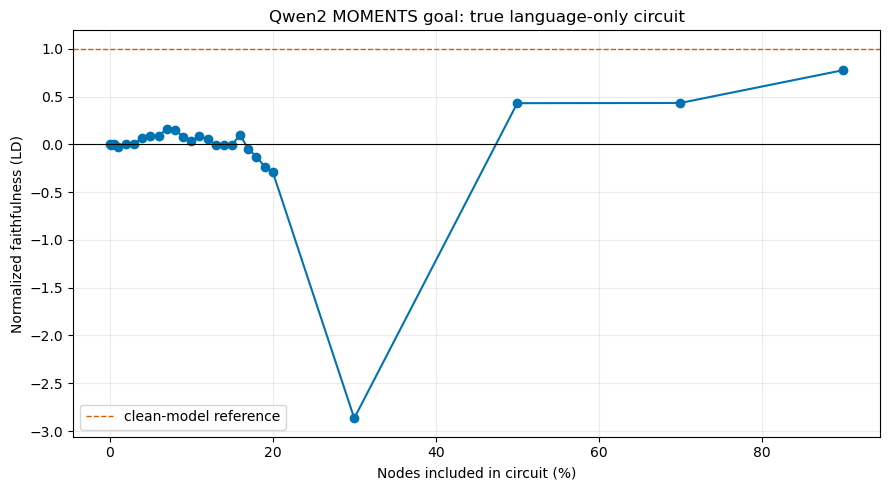

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(faithfulness_table['circuit_percent'], faithfulness_table['faithfulness_LD'], marker='o', color='#0173b2')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='#d55e00', linestyle='--', linewidth=1, label='clean-model reference')
ax.set_xlabel('Nodes included in circuit (%)')
ax.set_ylabel('Normalized faithfulness (LD)')
ax.set_title('Qwen2 MOMENTS goal: true language-only circuit')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'faithfulness_language_only_notebook.png', dpi=180)
plt.show()

## Attribution inputs

Each saved hook tensor is position-specific. MLP hooks normally have shape `[sequence position, neuron]`; attention `hook_z` tensors normally have shape `[sequence position, head, head dimension]`. The following cell summarizes the tensors before reducing them for visualization.

In [5]:
block_pattern = re.compile(r'blocks\.(\d+)\.')
rows = []
for hook_name, tensor in node_scores.items():
    match = block_pattern.search(str(hook_name))
    if match is None or tensor.ndim < 2:
        continue
    values = tensor.detach().float().cpu().abs()
    rows.append({
        'hook': str(hook_name),
        'layer': int(match.group(1)),
        'shape': tuple(values.shape),
        'mean_abs_score': float(values.mean()),
        'max_abs_score': float(values.max()),
    })

node_table = pd.DataFrame(rows).sort_values('max_abs_score', ascending=False)
node_table.head(20)

,hook,layer,shape,mean_abs_score,max_abs_score
52,blocks.1.mlp.hook_post,1,"(104, 18944)",0.000002,0.015577
0,blocks.27.mlp.hook_post,27,"(104, 18944)",0.000002,0.013509
50,blocks.2.mlp.hook_post,2,"(104, 18944)",0.000003,0.007471
54,blocks.0.mlp.hook_post,0,"(104, 18944)",0.000005,0.004682
20,blocks.17.mlp.hook_post,17,"(104, 18944)",0.000011,0.004423
36,blocks.9.mlp.hook_post,9,"(104, 18944)",0.000012,0.004003
10,blocks.22.mlp.hook_post,22,"(104, 18944)",0.000003,0.003468
46,blocks.4.mlp.hook_post,4,"(104, 18944)",0.000007,0.003451
34,blocks.10.mlp.hook_post,10,"(104, 18944)",0.000015,0.003354
16,blocks.19.mlp.hook_post,19,"(104, 18944)",0.000005,0.003212


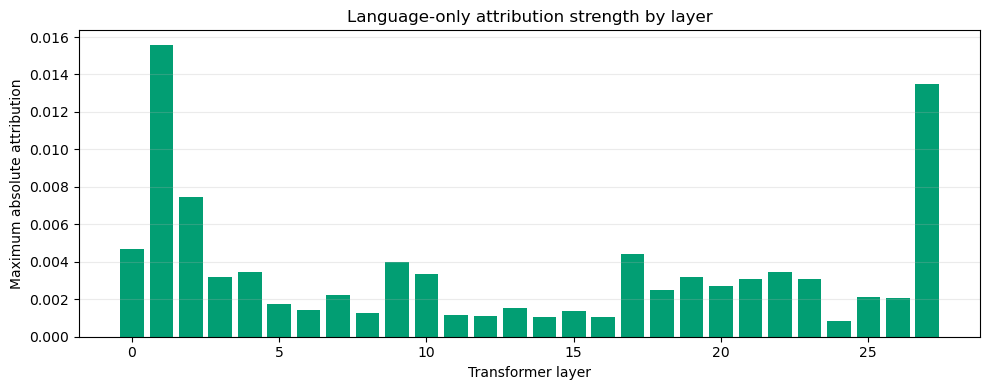

In [6]:
layer_table = (
    node_table.groupby('layer', as_index=False)['max_abs_score']
    .max()
    .sort_values('layer')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(layer_table['layer'], layer_table['max_abs_score'], color='#029e73')
ax.set_xlabel('Transformer layer')
ax.set_ylabel('Maximum absolute attribution')
ax.set_title('Language-only attribution strength by layer')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'attribution_by_layer_notebook.png', dpi=180)
plt.show()

Hook: blocks.1.mlp.hook_post
Shape: (104, 18944)


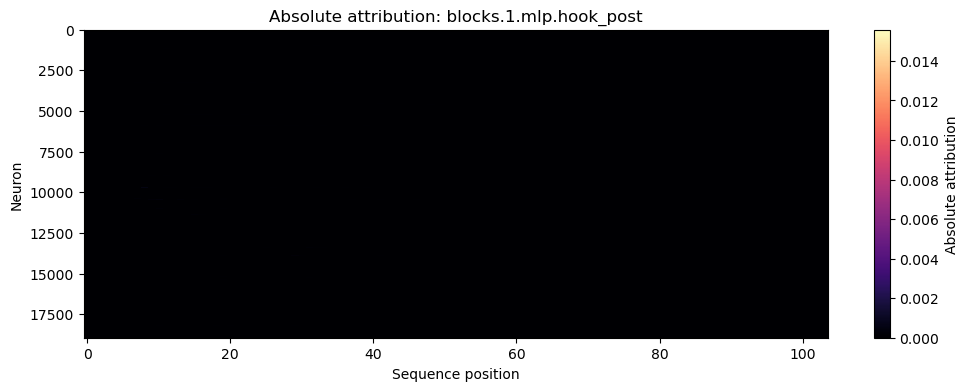

In [7]:
# Inspect one hook in detail: position x feature attribution.
HOOK_TO_INSPECT = node_table.iloc[0]['hook']
tensor = node_scores[HOOK_TO_INSPECT].detach().float().cpu().abs()
print('Hook:', HOOK_TO_INSPECT)
print('Shape:', tuple(tensor.shape))

if tensor.ndim == 2:
    plt.figure(figsize=(12, 4))
    plt.imshow(tensor.T, aspect='auto', interpolation='nearest', cmap='magma')
    plt.colorbar(label='Absolute attribution')
    plt.xlabel('Sequence position')
    plt.ylabel('Neuron')
    plt.title(f'Absolute attribution: {HOOK_TO_INSPECT}')
    plt.show()
elif tensor.ndim == 3:
    position_head = tensor.mean(dim=-1)
    plt.figure(figsize=(12, 4))
    plt.imshow(position_head.T, aspect='auto', interpolation='nearest', cmap='magma')
    plt.colorbar(label='Mean absolute attribution across head dimension')
    plt.xlabel('Sequence position')
    plt.ylabel('Attention head')
    plt.title(f'Absolute attribution by position and head: {HOOK_TO_INSPECT}')
    plt.show()

In [8]:
node_table.to_csv(OUTPUT_DIR / 'top_node_scores_notebook.csv', index=False)
faithfulness_table.to_csv(OUTPUT_DIR / 'faithfulness_language_only.csv', index=False)
print('Saved outputs to:', OUTPUT_DIR.resolve())

Saved outputs to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/language_only_results
